In [44]:
import pandas as pd 
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
def format_symbol(code):
    """
    Format stock symbol with proper prefix based on code
    """
    if code.startswith('6'):
        return f'sh{code}'
    elif code.startswith('9') or code.startswith('4'):
        return f'bj{code}'
    else:
        return f'sz{code}'

In [7]:
q4_stocks = pd.read_csv('../data/output/aligned_stock_code_pool.csv', dtype=str)
# change colunm name 
q4_stocks = q4_stocks.rename(columns={"Unnamed: 0": "stock_codes"})
q4_stocks

,stock_codes,201101,201102,201103,201104,201105,201106,201107,201108,201109,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,603077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,603766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,605368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,605377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
mask = q4_stocks.notna()
rightmost_col_idx = mask.iloc[:, ::-1].idxmax(axis=1)
rightmost_col_idx

0      201502
1      202105
2      202111
3      202311
4      201412
        ...  
149    202305
150    201708
151    202305
152    202411
153    202302
Length: 154, dtype: object

In [13]:
stock_last_seen = pd.concat([q4_stocks['stock_codes'], rightmost_col_idx], axis=1)
stock_last_seen = stock_last_seen.rename(columns={0: 'last_seen'})
# apply the format symbol function to the stock codes
stock_last_seen['stock_symbols'] = stock_last_seen['stock_codes'].apply(format_symbol)
stock_last_seen

,stock_codes,last_seen,stock_symbols
0,000001,201502,sz000001
1,000002,202105,sz000002
2,000039,202111,sz000039
3,000090,202311,sz000090
4,000100,201412,sz000100
...,...,...,...
149,603077,202305,sh603077
150,603766,201708,sh603766
151,605368,202305,sh605368
152,605377,202411,sh605377


In [40]:
stock_trends = {}

symbols = stock_last_seen['stock_symbols'].tolist()

for i, symbol in tqdm(enumerate(symbols)):
    
    last_seen_year = int(stock_last_seen['last_seen'][i][:4])
    last_seen_month = int(stock_last_seen['last_seen'][i][4:6])
    # print(symbol, last_seen_year, last_seen_month)

    # load the price data
    price_df = pd.read_csv(f"../data/input/price-data/20260109/price_data_{symbol}_20260109.csv")
    price_df['report_date'] = pd.to_datetime(price_df['report_date'])
    price_df['year'] = price_df['report_date'].dt.year
    price_df['month'] = price_df['report_date'].dt.month

    # find the last seen row 
    last_seen_row = price_df.query(f"year == {last_seen_year} and month == {last_seen_month}")
    last_seen_row_date = last_seen_row.iloc[-1]['report_date']
    last_seen_row_price = last_seen_row.iloc[-1]['close']
    # print(last_seen_row_price, last_seen_row_date)

    # find the row with the max close price
    max_close_price_row = price_df.loc[price_df.query(f"year >= {last_seen_year} and month >= {last_seen_month}")['close'].idxmax()]
    max_close_price = max_close_price_row['close']
    max_close_price_date = max_close_price_row['report_date']
    max_close_price_year = max_close_price_date.year
    max_close_price_month = max_close_price_date.month

    # print(max_close_price, max_close_price_date, max_close_price_year, max_close_price_month)
    stock_trends[symbol] = [last_seen_row_date, last_seen_year, last_seen_month, last_seen_row_price, 
                            max_close_price_date, max_close_price_year, max_close_price_month, max_close_price]
stock_trends_df = pd.DataFrame.from_dict(stock_trends, orient='index', columns=[
    'last_seen_date', 'last_seen_year', 'last_seen_month', 'last_seen_price',
    'max_close_date', 'max_close_year', 'max_close_month', 'max_close_price'
])
stock_trends_df

154it [00:00, 249.26it/s]


,last_seen_date,last_seen_year,last_seen_month,last_seen_price,max_close_date,max_close_year,max_close_month,max_close_price
sz000001,2015-02-27,2015,2,13.99,2021-05-26,2021,5,25.01
sz000002,2021-05-31,2021,5,26.70,2021-05-07,2021,5,28.00
sz000039,2021-11-30,2021,11,17.03,2021-12-03,2021,12,17.41
sz000090,2023-11-30,2023,11,5.07,2023-11-14,2023,11,5.54
sz000100,2014-12-31,2014,12,3.80,2020-12-02,2020,12,8.01
...,...,...,...,...,...,...,...,...
sh603077,2023-05-31,2023,5,2.35,2023-05-04,2023,5,2.70
sh603766,2017-08-31,2017,8,7.70,2025-12-17,2025,12,16.29
sh605368,2023-05-31,2023,5,9.37,2024-08-22,2024,8,14.50
sh605377,2024-11-29,2024,11,12.64,2024-12-12,2024,12,13.86


In [41]:
stock_trends_recent = stock_trends_df.query("last_seen_year < 2025").copy()
stock_trends_recent['price_change'] = stock_trends_recent['max_close_price'] - stock_trends_recent['last_seen_price']
stock_trends_recent['price_change_pct'] = stock_trends_recent['price_change'] / stock_trends_recent['last_seen_price'] * 100
stock_trends_recent['date gap'] = (stock_trends_recent['max_close_date'] - stock_trends_recent['last_seen_date']).dt.days

stock_trends_recent

,last_seen_date,last_seen_year,last_seen_month,last_seen_price,max_close_date,max_close_year,max_close_month,max_close_price,price_change,price_change_pct,date gap
sz000001,2015-02-27,2015,2,13.99,2021-05-26,2021,5,25.01,11.02,78.770550,2280
sz000002,2021-05-31,2021,5,26.70,2021-05-07,2021,5,28.00,1.30,4.868914,-24
sz000039,2021-11-30,2021,11,17.03,2021-12-03,2021,12,17.41,0.38,2.231356,3
sz000090,2023-11-30,2023,11,5.07,2023-11-14,2023,11,5.54,0.47,9.270217,-16
sz000100,2014-12-31,2014,12,3.80,2020-12-02,2020,12,8.01,4.21,110.789474,2163
...,...,...,...,...,...,...,...,...,...,...,...
sh603077,2023-05-31,2023,5,2.35,2023-05-04,2023,5,2.70,0.35,14.893617,-27
sh603766,2017-08-31,2017,8,7.70,2025-12-17,2025,12,16.29,8.59,111.558442,3030
sh605368,2023-05-31,2023,5,9.37,2024-08-22,2024,8,14.50,5.13,54.749200,449
sh605377,2024-11-29,2024,11,12.64,2024-12-12,2024,12,13.86,1.22,9.651899,13


(array([59., 28., 13.,  7.,  5.,  3.,  1.,  2.,  1.,  3.]),
 array([  1.33079848,  55.95962339, 110.58844831, 165.21727322,
        219.84609814, 274.47492305, 329.10374796, 383.73257288,
        438.36139779, 492.99022271, 547.61904762]),
 <BarContainer object of 10 artists>)

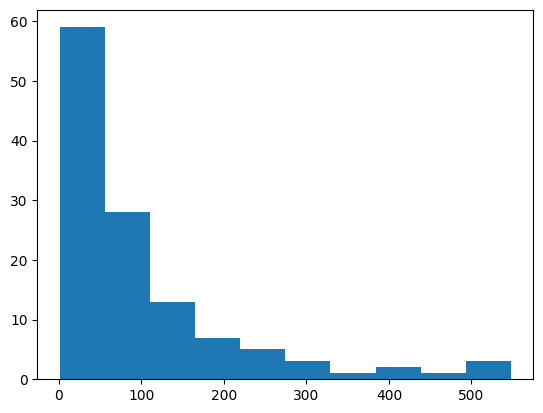

In [46]:
qualified_stocks = stock_trends_recent[stock_trends_recent['last_seen_date'] < stock_trends_recent['max_close_date']]
plt.hist(qualified_stocks['price_change_pct'])

(array([39., 22., 20.,  6.,  9.,  8.,  2.,  7.,  4.,  5.]),
 array([2.0000e+00, 4.0670e+02, 8.1140e+02, 1.2161e+03, 1.6208e+03,
        2.0255e+03, 2.4302e+03, 2.8349e+03, 3.2396e+03, 3.6443e+03,
        4.0490e+03]),
 <BarContainer object of 10 artists>)

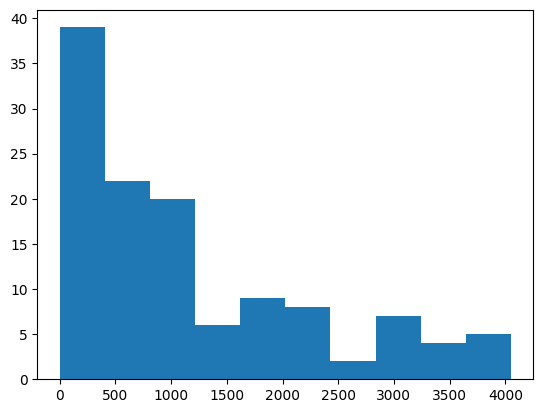

In [48]:
plt.hist(qualified_stocks['date gap'])

In [57]:
qualified_stocks.reset_index().query("index == 'sh600606'")

,index,last_seen_date,last_seen_year,last_seen_month,last_seen_price,max_close_date,max_close_year,max_close_month,max_close_price,price_change,price_change_pct,date gap


In [58]:
stock_trends_recent.reset_index().query("index == 'sh600606'")

,index,last_seen_date,last_seen_year,last_seen_month,last_seen_price,max_close_date,max_close_year,max_close_month,max_close_price,price_change,price_change_pct,date gap
77,sh600606,2021-02-26,2021,2,5.63,2021-02-25,2021,2,6.0,0.37,6.571936,-1


In [59]:
qualified_stocks.shape[0] /stock_trends_recent.shape[0]

0.8840579710144928

In [55]:
qualified_stocks['price_change_pct'].mean()

np.float64(99.65842244190196)

In [56]:
qualified_stocks['date gap'].mean()

np.float64(1156.8360655737704)

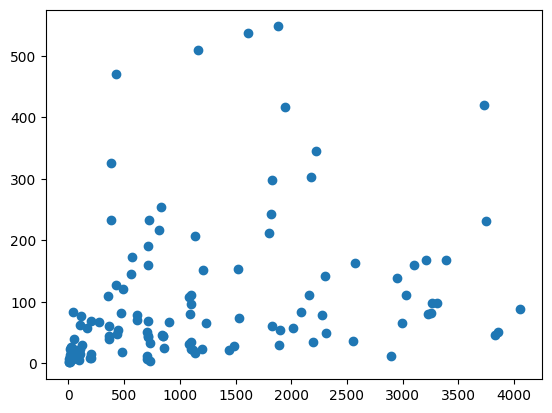

In [60]:
plt.scatter(qualified_stocks['date gap'], qualified_stocks['price_change_pct'])